# Atividade 08 — Expansão e Regularização

**Script R equivalente:** [`../scriptsR/08-regularizacao.R`](../scriptsR/08-regularizacao.R)

**Explicação detalhada (consolidado):** [consolidado/08-regularizacao.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/08-regularizacao.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_60_69`. Preditores válidos (excluídos `ipdm` e `longevidade`).

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 08
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade requer o pacote glmnet.

if (!requireNamespace("glmnet", quietly = TRUE)) {
  install.packages("glmnet", repos = "https://cloud.r-project.org")
}
library(glmnet)

options(repr.plot.width = 8, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

Carregando pacotes exigidos: Matrix

Loaded glmnet 5.1



[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 08
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"
origem_dados <- if (file.exists(arquivo_local)) arquivo_local else url_github
if (file.exists(arquivo_local)) cat("[INFO] Carregando banco LOCAL.\n") else cat("[INFO] Carregando do GitHub.\n")

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  ano               = as.integer(dados_brutos[[3]]),
  riqueza           = as.numeric(dados_brutos[[4]]),
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]]),
  distorcao_em      = as.numeric(dados_brutos[[9]]),
  pib_per_capita    = as.numeric(dados_brutos[[10]])
)

# Expansao: termos polinomiais e interacoes
dados$escolaridade2    <- dados$escolaridade^2
dados$distorcao_x_esc  <- dados$distorcao_em * dados$escolaridade

X <- as.matrix(dados[, c("escolaridade","escolaridade2","distorcao_em",
                         "distorcao_x_esc","pib_per_capita","riqueza","ano")])
y <- dados$mortalidade_60_69
n <- nrow(X); p <- ncol(X)

cat("[INFO] Dados carregados:", n, "linhas |", p, "preditores.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas | 7 preditores.


In [3]:
# =============================================================
# ANALISE — Atividade 08
# =============================================================
# MQO de referencia
m_mqo <- lm(mortalidade_60_69 ~ escolaridade + escolaridade2 + distorcao_em +
              distorcao_x_esc + pib_per_capita + riqueza + ano, data = dados)
cat("\n================ MQO DE REFERENCIA ================\n")
cat("R2 =", round(summary(m_mqo)$r.squared, 4),
    "| R2 aj =", round(summary(m_mqo)$adj.r.squared, 4), "\n")

# Cross-validation glmnet
set.seed(1)
cv_ridge <- cv.glmnet(X, y, alpha = 0)
cv_lasso <- cv.glmnet(X, y, alpha = 1)
cv_enet  <- cv.glmnet(X, y, alpha = 0.5)

cat("\n================ CROSS-VALIDATION glmnet ================\n")
print(data.frame(
  Modelo = c("Ridge (a=0)", "ElasticNet (a=0.5)", "Lasso (a=1)"),
  Lambda_min = round(c(cv_ridge$lambda.min, cv_enet$lambda.min, cv_lasso$lambda.min), 4),
  MSE_min    = round(c(min(cv_ridge$cvm), min(cv_enet$cvm), min(cv_lasso$cvm)), 4),
  Lambda_1se = round(c(cv_ridge$lambda.1se, cv_enet$lambda.1se, cv_lasso$lambda.1se), 4)
))

coef_r <- coef(cv_ridge, s = "lambda.1se")
coef_l <- coef(cv_lasso, s = "lambda.1se")
cat("\n================ COEFICIENTES (lambda.1se) ================\n")
cat("--- Ridge ---\n"); print(round(as.matrix(coef_r), 4))
cat("\n--- Lasso ---\n"); print(round(as.matrix(coef_l), 4))

sobrev_r <- rownames(coef_r)[as.vector(coef_r) != 0]
sobrev_l <- rownames(coef_l)[as.vector(coef_l) != 0]
cat("\nSobreviventes Ridge:", paste(sobrev_r, collapse = ", "), "\n")
cat("Sobreviventes Lasso:", paste(sobrev_l, collapse = ", "), "\n")

# Teste 70/30
set.seed(1); idx <- sample(seq_len(n), floor(0.7*n))
Xtr <- X[idx,]; Xte <- X[-idx,]; ytr <- y[idx]; yte <- y[-idx]

pred_mqo <- predict(m_mqo, newdata = dados[-idx,])
cv_l_tr <- cv.glmnet(Xtr, ytr, alpha = 1)
cv_r_tr <- cv.glmnet(Xtr, ytr, alpha = 0)
pred_l <- as.vector(predict(cv_l_tr, Xte, s = "lambda.1se"))
pred_r <- as.vector(predict(cv_r_tr, Xte, s = "lambda.1se"))

rmse <- function(y, yh) sqrt(mean((y - yh)^2))
cat("\n================ TESTE (RMSE) ================\n")
print(data.frame(
  Modelo = c("Baseline (media treino)", "MQO", "Ridge (1se)", "Lasso (1se)"),
  RMSE = round(c(rmse(yte, rep(mean(ytr), length(yte))),
                 rmse(yte, pred_mqo), rmse(yte, pred_r), rmse(yte, pred_l)), 4)
))


================ MQO DE REFERENCIA ================
R2 = 0.229 | R2 aj = 0.1117 

================ CROSS-VALIDATION glmnet ================
              Modelo Lambda_min MSE_min Lambda_1se
1        Ridge (a=0)     5.6484 14.1445  1500.2667
2 ElasticNet (a=0.5)     1.2989 14.5705     3.0005
3        Lasso (a=1)     0.5392 14.1402     1.5003

================ COEFICIENTES (lambda.1se) ================
--- Ridge ---
                lambda.1se
(Intercept)        19.9056
escolaridade        0.0000
escolaridade2       0.0000
distorcao_em        0.0000
distorcao_x_esc     0.0000
pib_per_capita      0.0000
riqueza             0.0000
ano                 0.0000

--- Lasso ---
                lambda.1se
(Intercept)        19.9056
escolaridade        0.0000
escolaridade2       0.0000
distorcao_em        0.0000
distorcao_x_esc     0.0000
pib_per_capita      0.0000
riqueza             0.0000
ano                 0.0000

Sobreviventes Ridge: (Intercept), escolaridade, escolaridade2, distorcao_em, d

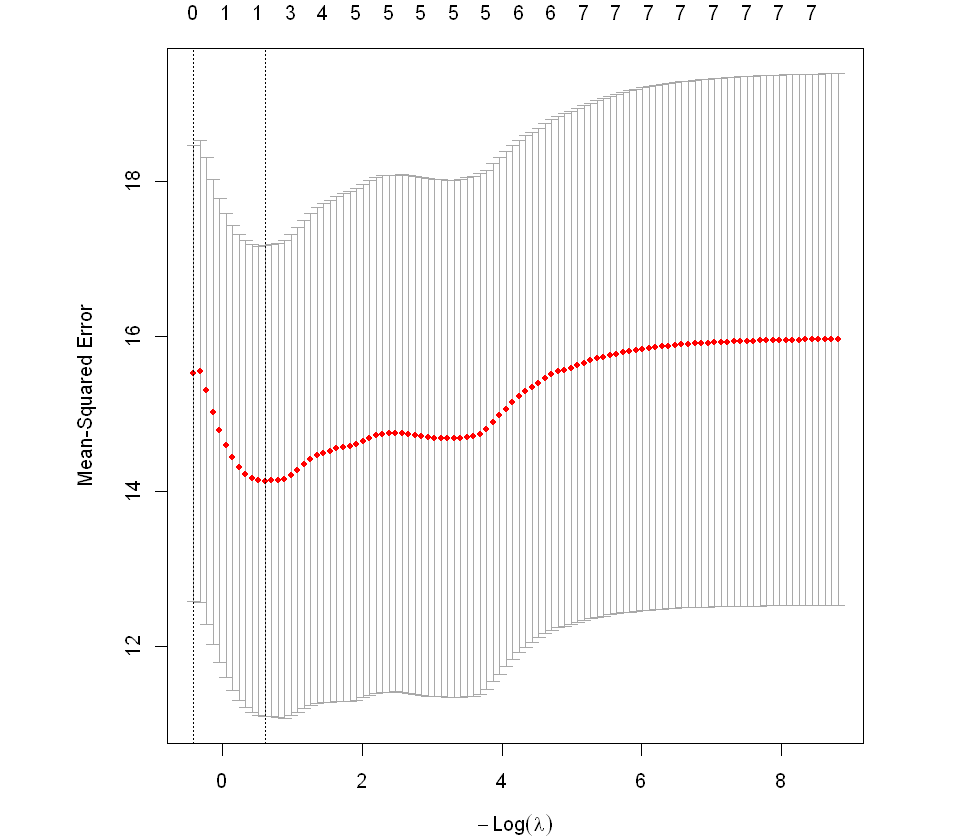

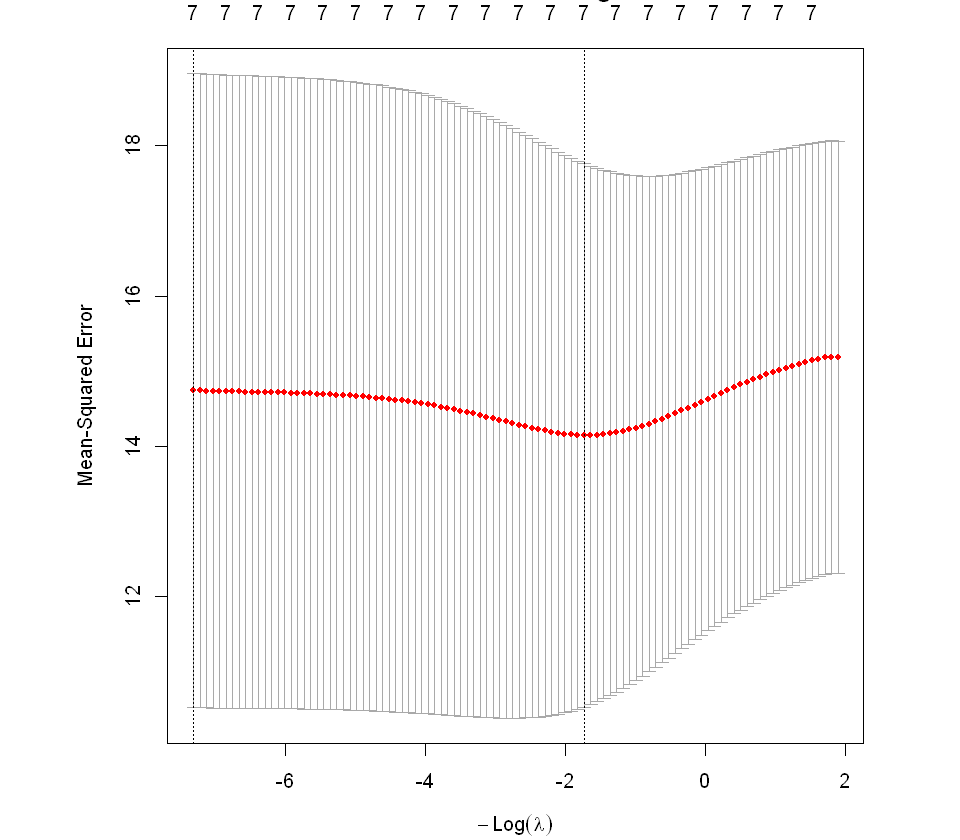

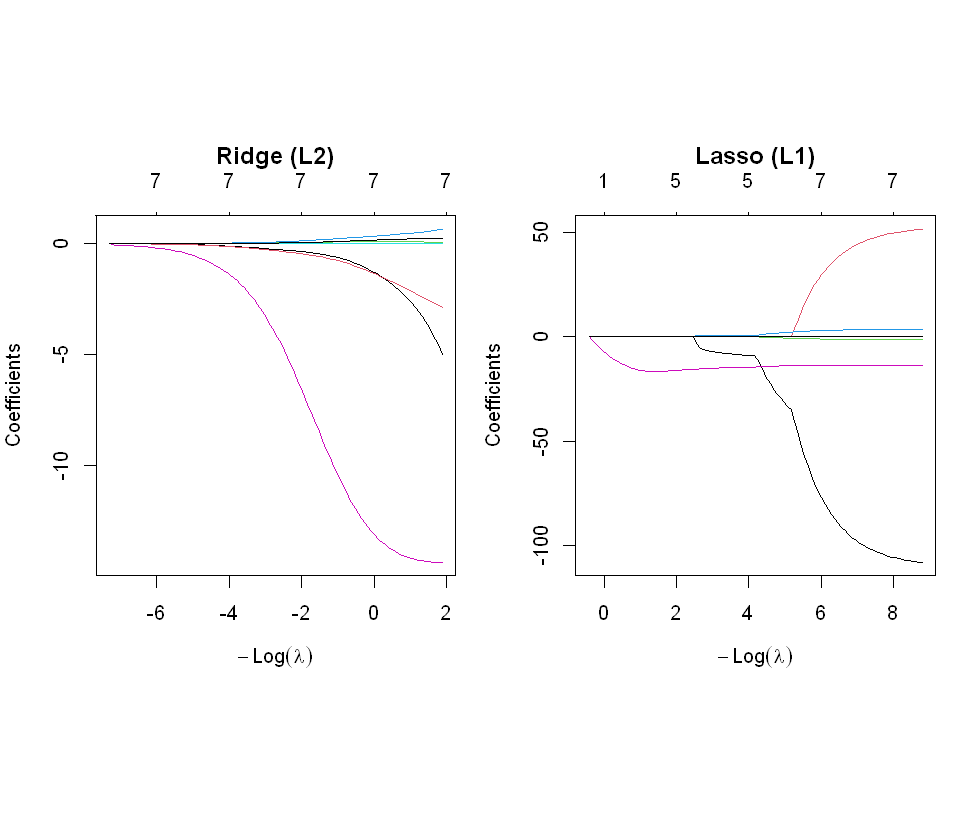

In [4]:
# =============================================================
# GRAFICOS — Atividade 08
# =============================================================
# Grafico 1 — curva em U (Lasso)
par(mar = c(4,4,2,1), pty = "s")
plot(cv_lasso); title("Curva em U - Lasso", line = 2.2)

# Grafico 2 — curva em U (Ridge)
par(mar = c(4,4,2,1), pty = "s")
plot(cv_ridge); title("Curva em U - Ridge", line = 2.2)

# Grafico 3 — trilhas de coeficientes (Ridge vs Lasso)
m_ridge_path <- glmnet(X, y, alpha = 0)
m_lasso_path <- glmnet(X, y, alpha = 1)

par(mfrow = c(1,2), mar = c(4,4,2,1), pty = "s")
plot(m_ridge_path, xvar = "lambda"); title("Ridge (L2)", line = 2.2)
plot(m_lasso_path, xvar = "lambda"); title("Lasso (L1)", line = 2.2)